In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [3]:
df=pd.read_csv("C:/Users/kuzma/OneDrive/Desktop/DATA ANALYST/Ride_Fare_Surge_Analysis/data/rides.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.shape

(150000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [7]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [9]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [17]:
print(df['Time'].head())
print(type(df['Time'].iloc[0]))

0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: object
<class 'datetime.time'>


In [19]:
df['Date']=pd.to_datetime(df['Date'])
df['Hour'] = df['Time'].apply(lambda x: x.hour)
df['Minute'] = df['Time'].apply(lambda x: x.minute)

In [22]:
print(df[['Driver Ratings', 'Customer Rating']].dtypes)

print(df[['Driver Ratings', 'Customer Rating']].head())

print(df[['Driver Ratings', 'Customer Rating']].isnull().sum())

Driver Ratings     float64
Customer Rating    float64
dtype: object
   Driver Ratings  Customer Rating
0             4.3              4.5
1             4.3              4.5
2             4.9              4.9
3             4.6              5.0
4             4.1              4.3
Driver Ratings     0
Customer Rating    0
dtype: int64


In [24]:
df['Driver Ratings'] = pd.to_numeric(df['Driver Ratings'], errors='coerce')
df['Customer Rating'] = pd.to_numeric(df['Customer Rating'], errors='coerce')

df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].median())
df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].median())

# Feature Engineering

In [157]:
# Fare per KM
df['Fare_per_KM'] = df['Booking Value'] / df['Ride Distance']

# Hour
df['Hour'] = df['Time'].apply(lambda x: x.hour)

# Minute
df['Minute'] = df['Time'].apply(lambda x: x.minute)

# Weekday
df['Weekday'] = df['Date'].dt.day_name()

# Month
df['Month'] = df['Date'].dt.month_name()

# -------------------------------
# Features only for Completed Rides
# -------------------------------

# Initialize new columns
df['Fare_per_KM'] = np.nan
df['Distance Category'] = pd.Categorical(
    df['Distance Category'],
    categories=[
        '0-5 KM',
        '5-10 KM',
        '10-15 KM',
        '15-20 KM',
        '20-25 KM',
        '25-30 KM',
        '30-40 KM',
        '40-50 KM'
    ],
    ordered=True
)
df['Distance Category'].dtype

df['Surge'] = 'Not Applicable'

# Completed rides only
mask = df['Booking Status'] == 'Completed'

# Fare per KM
df.loc[mask, 'Fare_per_KM'] = (
    df.loc[mask, 'Booking Value'] /
    df.loc[mask, 'Ride Distance']
)

# Distance Category
df.loc[mask, 'Distance Category'] = pd.cut(
    df.loc[mask, 'Ride Distance'],
    bins=[0,5,10,15,20,25,30,40,50],
    labels=[
        '0-5 KM',
        '5-10 KM',
        '10-15 KM',
        '15-20 KM',
        '20-25 KM',
        '25-30 KM',
        '30-40 KM',
        '40-50 KM'
    ]
)

# Surge Classification
avg_fare = df.loc[mask, 'Fare_per_KM'].mean()

df.loc[mask, 'Surge'] = np.where(
    df.loc[mask, 'Fare_per_KM'] > avg_fare * 1.3,
    'Surge',
    'Normal'
)

# Verify 
df[['Booking Status', 'Booking Value', 'Ride Distance',
    'Fare_per_KM', 'Distance Category', 'Surge']].sample(10, random_state=42)

,Booking Status,Booking Value,Ride Distance,Fare_per_KM,Distance Category,Surge
59770,Cancelled by Customer,NaN,NaN,NaN,NaN,Not Applicable
21362,Completed,269.0,47.17,5.702777,40-50 KM,Normal
127324,Completed,352.0,9.57,36.781609,5-10 KM,Normal
140509,Completed,313.0,48.18,6.496472,40-50 KM,Normal
144297,Completed,365.0,12.06,30.265340,10-15 KM,Normal
96370,Completed,638.0,24.28,26.276771,20-25 KM,Normal
49742,No Driver Found,NaN,NaN,NaN,NaN,Not Applicable
47389,Completed,887.0,19.40,45.721649,15-20 KM,Surge
58378,Completed,221.0,13.83,15.979754,10-15 KM,Normal
69047,Completed,367.0,38.51,9.529992,30-40 KM,Normal


# Data Cleaning 

In [110]:
# Missing Values Analysis

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round((df.isnull().sum()/len(df))*100,2)
})

missing = missing[missing['Missing Values'] > 0]

missing.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage
Incomplete Rides,141000,94.0
Incomplete Rides Reason,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Cancelled Rides by Driver,123000,82.0
Driver Cancellation Reason,123000,82.0
Avg CTAT,48000,32.0
Booking Value,48000,32.0
Ride Distance,48000,32.0
Payment Method,48000,32.0


In [111]:
#Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [112]:
# Datatypes 
df.dtypes

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

In [126]:
# Handle Missing Values

#RATINGS 
df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].median())

df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].median())

# Cancellation reasons:
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna("Not Cancelled")

df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna("Not Cancelled")

# Incomplete rides:
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna("Ride Completed")

In [117]:
# Recheck
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer         0
Cancelled Rides by Driver            123000
Driver Cancellation Reason                0
Incomplete Rides                     141000
Incomplete Rides Reason                   0
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                            0
Customer Rating                           0
Payment Method                        48000
Hour                                      0
Minute                          

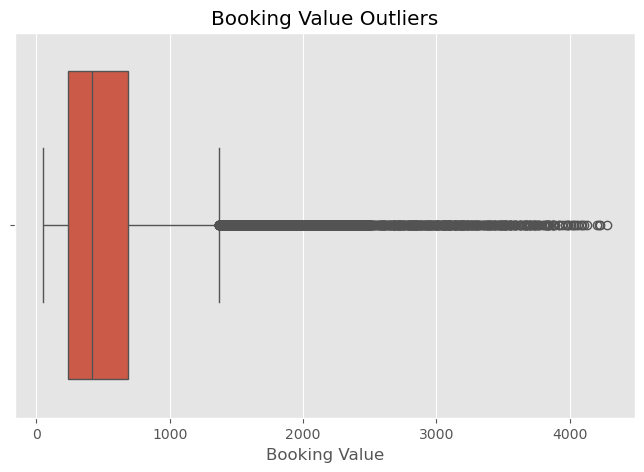


-------------------------------------------------------------------------------------------------------------------------


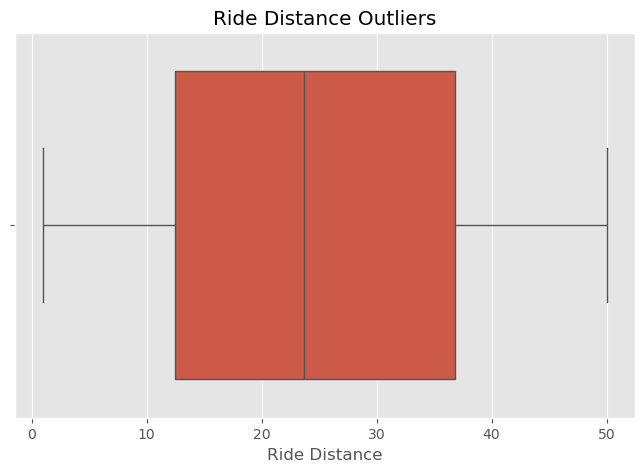

In [123]:
# Outlier Detection

# Booking Value
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Booking Value'])

plt.title("Booking Value Outliers")

plt.show()

print ("\n-------------------------------------------------------------------------------------------------------------------------")

# Ride Distance
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Ride Distance'])

plt.title("Ride Distance Outliers")

plt.show()

In [124]:
# Invalid Values
print(df.describe())

                             Date       Avg VTAT       Avg CTAT  \
count                      150000  139500.000000  102000.000000   
mean   2024-06-30 16:42:40.320000       8.456352      29.149636   
min           2024-01-01 00:00:00       2.000000      10.000000   
25%           2024-03-31 00:00:00       5.300000      21.600000   
50%           2024-07-01 00:00:00       8.300000      28.800000   
75%           2024-09-30 00:00:00      11.300000      36.800000   
max           2024-12-30 00:00:00      20.000000      45.000000   
std                           NaN       3.773564       8.902577   

       Cancelled Rides by Customer  Cancelled Rides by Driver  \
count                      10500.0                    27000.0   
mean                           1.0                        1.0   
min                            1.0                        1.0   
25%                            1.0                        1.0   
50%                            1.0                        1.0   
75%   

In [125]:
# Final Check
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [129]:
df['Booking Status'].value_counts()
completed_df = df[df['Booking Status'] == 'Completed'].copy()
print(completed_df.shape)

(93000, 28)


In [132]:
# Recalculate Fare_per_KM  
completed_df['Fare_per_KM'] = (
    completed_df['Booking Value'] /
    completed_df['Ride Distance']
)

In [133]:
# Recreate Distance Category
completed_df['Distance Category'] = pd.cut(
    completed_df['Ride Distance'],
    bins=[0,5,10,15,20,25,30,40,50],
    labels=[
        '0-5 KM',
        '5-10 KM',
        '10-15 KM',
        '15-20 KM',
        '20-25 KM',
        '25-30 KM',
        '30-40 KM',
        '40-50 KM'
    ]
)

In [135]:
# Surge Detection
avg_fare = completed_df['Fare_per_KM'].mean()

completed_df['Surge'] = np.where(
    completed_df['Fare_per_KM'] > avg_fare * 1.3,
    'Surge',
    'Normal'
)

#Check
completed_df['Surge'].value_counts()

Surge
Normal    74802
Surge     18198
Name: count, dtype: int64

# EDA 

# 1. Dataset Overview

In [27]:
print("Rows & Columns :", df.shape)

Rows & Columns : (150000, 26)


In [28]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Hour', 'Minute',
       'Fare_per_KM', 'Weekday', 'Month'],
      dtype='object')


In [29]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64

In [30]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                            0
Customer Rating                           0
Payment Method                        48000
Hour                                      0
Minute         

# 2. Booking Status Analysis

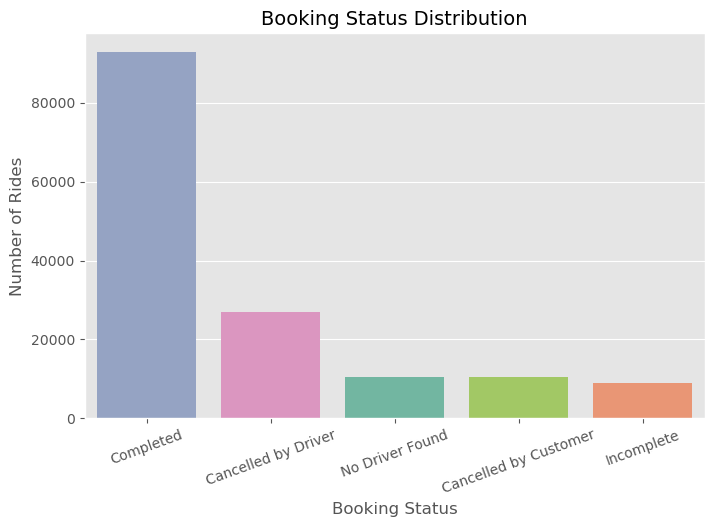

Booking Status Percentage (%)
Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


In [158]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Booking Status',
    order=df['Booking Status'].value_counts().index,
    palette='Set2',
    hue='Booking Status',      # Different color for each status
    legend=False
)

plt.title("Booking Status Distribution", fontsize=14)
plt.xlabel("Booking Status")
plt.ylabel("Number of Rides")
plt.xticks(rotation=20)

plt.show()

# Percentage
booking_status = df['Booking Status'].value_counts(normalize=True) * 100

print("Booking Status Percentage (%)")
print(booking_status.round(2))

# 3. Vehicle Type Analysis

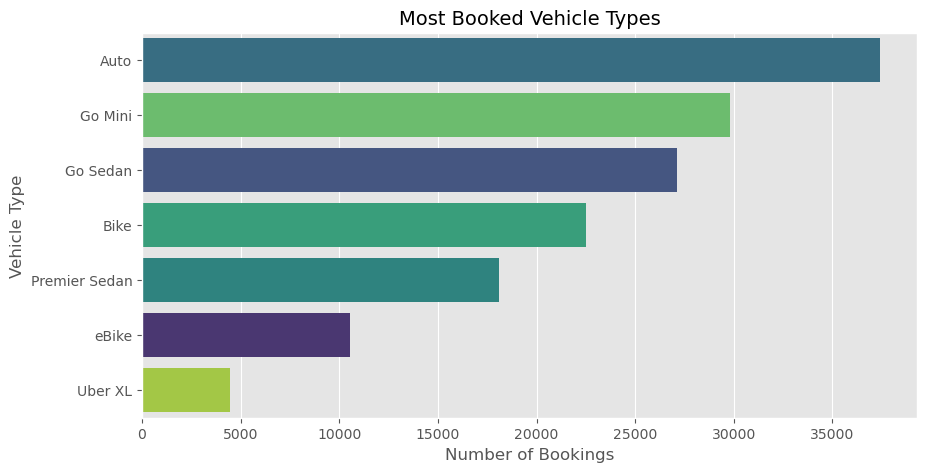

Vehicle Type Percentage (%)
Vehicle Type
Auto             24.95
Go Mini          19.87
Go Sedan         18.09
Bike             15.01
Premier Sedan    12.07
eBike             7.04
Uber XL           2.97
Name: proportion, dtype: float64


In [159]:
# Vehicle Type Analysis (Most Booked Vehicle)

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Vehicle Type',
    order=df['Vehicle Type'].value_counts().index,
    hue='Vehicle Type',
    palette='viridis',
    legend=False
)

plt.title("Most Booked Vehicle Types", fontsize=14)
plt.xlabel("Number of Bookings")
plt.ylabel("Vehicle Type")

plt.show()

# Percentage
vehicle_percent = (df['Vehicle Type'].value_counts(normalize=True) * 100).round(2)

print("Vehicle Type Percentage (%)")
print(vehicle_percent)

# 4. Average FARE by Vehicle

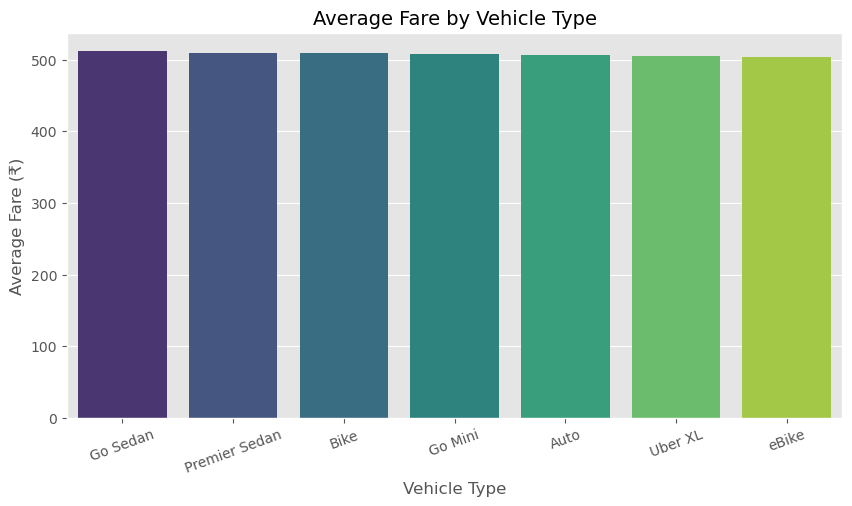

Average Fare by Vehicle
Vehicle Type
Go Sedan         512.03
Premier Sedan    509.57
Bike             509.11
Go Mini          507.38
Auto             506.48
Uber XL          505.30
eBike            503.46
Name: Booking Value, dtype: float64


In [160]:
# Average Fare by Vehicle Type (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

vehicle_fare = (
    completed.groupby('Vehicle Type')['Booking Value']
             .mean()
             .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=vehicle_fare.index,
    y=vehicle_fare.values,
    hue=vehicle_fare.index,
    palette='viridis',
    legend=False
)

plt.title("Average Fare by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Average Fare (₹)")
plt.xticks(rotation=20)

plt.show()

print("Average Fare by Vehicle")
print(vehicle_fare.round(2))

# 5. Ride Distance Analysis

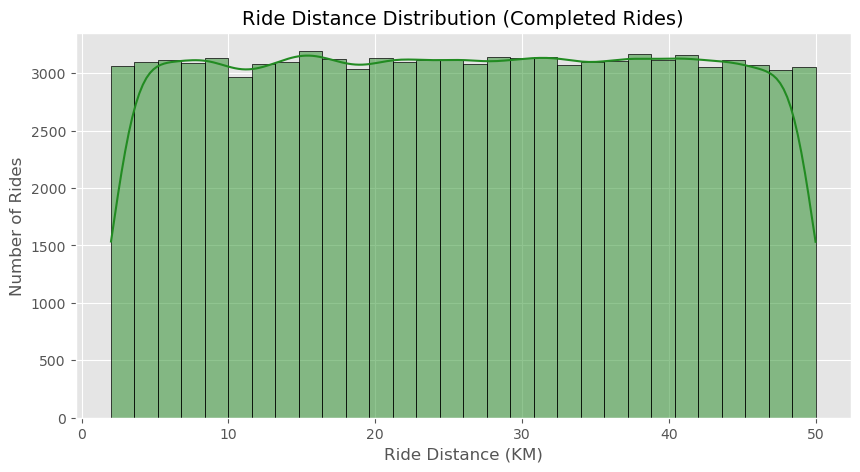

Ride Distance Statistics
count    93000.00
mean        26.00
std         13.82
min          2.00
25%         14.10
50%         26.02
75%         37.94
max         50.00
Name: Ride Distance, dtype: float64


In [163]:
# Ride Distance Distribution (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(10,5))

sns.histplot(
    data=completed,
    x='Ride Distance',
    bins=30,
    kde=True,
    color='forestgreen',
    edgecolor='black'
)

plt.title("Ride Distance Distribution (Completed Rides)", fontsize=14)
plt.xlabel("Ride Distance (KM)")
plt.ylabel("Number of Rides")

plt.show()

# Statistics
print("Ride Distance Statistics")
print(completed['Ride Distance'].describe().round(2))

# 6. Booking Value Distribution

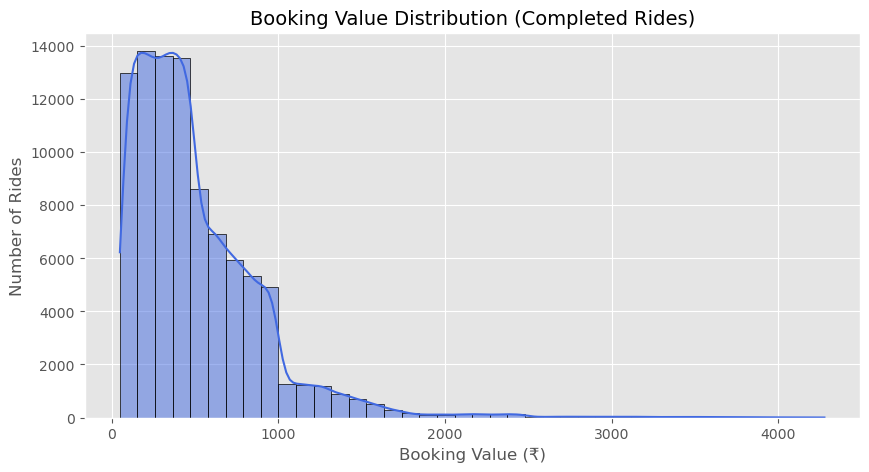

Booking Value Statistics
count    93000.00
mean       508.18
std        396.06
min         50.00
25%        234.00
50%        414.00
75%        689.00
max       4277.00
Name: Booking Value, dtype: float64


In [164]:
# Booking Value Distribution (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(10,5))

sns.histplot(
    data=completed,
    x='Booking Value',
    bins=40,
    kde=True,
    color='royalblue',
    edgecolor='black'
)

plt.title("Booking Value Distribution (Completed Rides)", fontsize=14)
plt.xlabel("Booking Value (₹)")
plt.ylabel("Number of Rides")

plt.show()

# Statistics
print("Booking Value Statistics")
print(completed['Booking Value'].describe().round(2))

# 7. Ride Distance Vs Booking Value

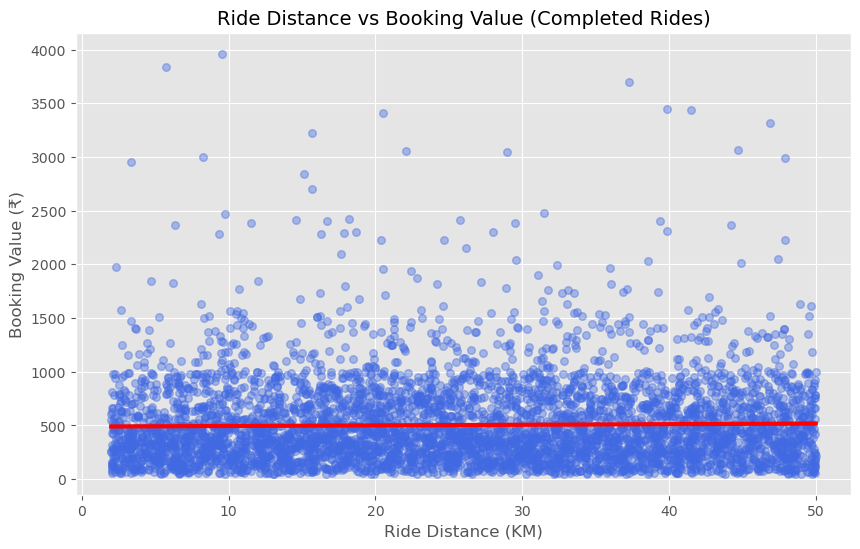

Correlation between Ride Distance and Booking Value: 0.01


In [165]:
# Ride Distance vs Booking Value (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

# Sample for faster plotting
sample = completed.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sample,
    x='Ride Distance',
    y='Booking Value',
    scatter_kws={
        'color': 'royalblue',
        'alpha': 0.4,
        's': 30
    },
    line_kws={
        'color': 'red',
        'linewidth': 3
    }
)

plt.title("Ride Distance vs Booking Value (Completed Rides)", fontsize=14)
plt.xlabel("Ride Distance (KM)")
plt.ylabel("Booking Value (₹)")

plt.show()

# Correlation
correlation = completed['Ride Distance'].corr(completed['Booking Value'])
print(f"Correlation between Ride Distance and Booking Value: {correlation:.2f}")

# 8. Peak Booking Hours

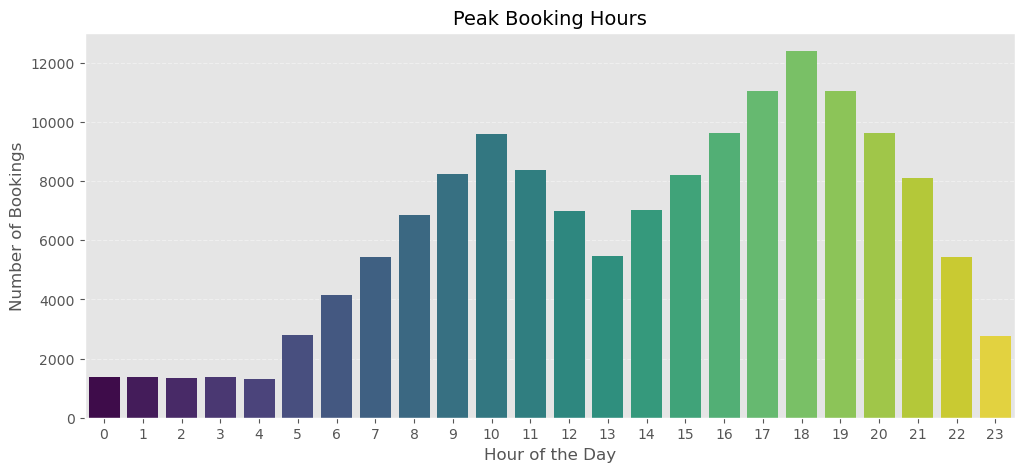

Bookings by Hour
Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64


In [166]:
# Peak Booking Hours

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Hour',
    hue='Hour',          # Different color for each hour
    palette='viridis',
    legend=False
)

plt.title("Peak Booking Hours", fontsize=14)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Bookings")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Booking count by hour
hourly_bookings = df['Hour'].value_counts().sort_index()

print("Bookings by Hour")
print(hourly_bookings)

# 9. Average Fare by Hour

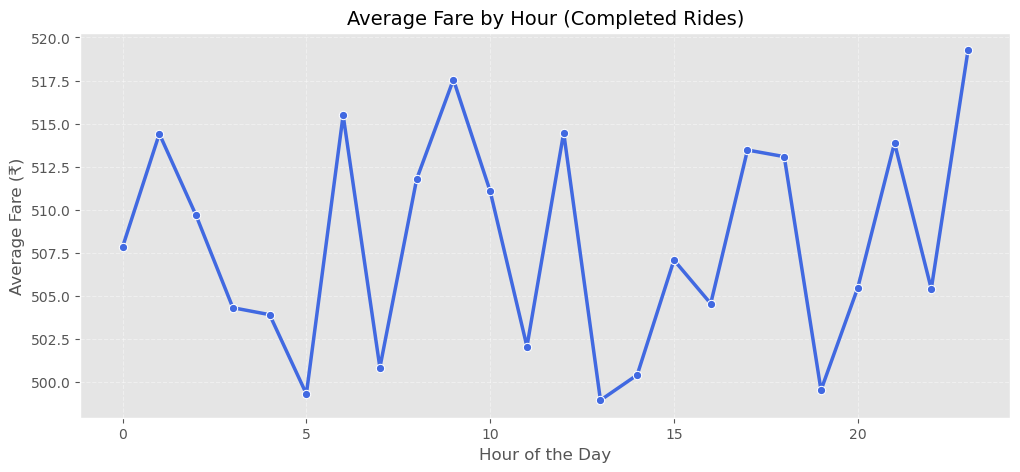

Average Fare by Hour
    Hour  Booking Value
0      0         507.84
1      1         514.41
2      2         509.67
3      3         504.32
4      4         503.91
5      5         499.31
6      6         515.49
7      7         500.84
8      8         511.78
9      9         517.56
10    10         511.08
11    11         502.06
12    12         514.47
13    13         498.95
14    14         500.42
15    15         507.08
16    16         504.56
17    17         513.47
18    18         513.08
19    19         499.53
20    20         505.47
21    21         513.88
22    22         505.41
23    23         519.26


In [167]:
# Average Fare by Hour (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

hourly_fare = (
    completed.groupby('Hour')['Booking Value']
             .mean()
             .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_fare,
    x='Hour',
    y='Booking Value',
    marker='o',
    color='royalblue',
    linewidth=2.5
)

plt.title("Average Fare by Hour (Completed Rides)", fontsize=14)
plt.xlabel("Hour of the Day")
plt.ylabel("Average Fare (₹)")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

print("Average Fare by Hour")
print(hourly_fare.round(2))

# 10. Customer Rating Analysis

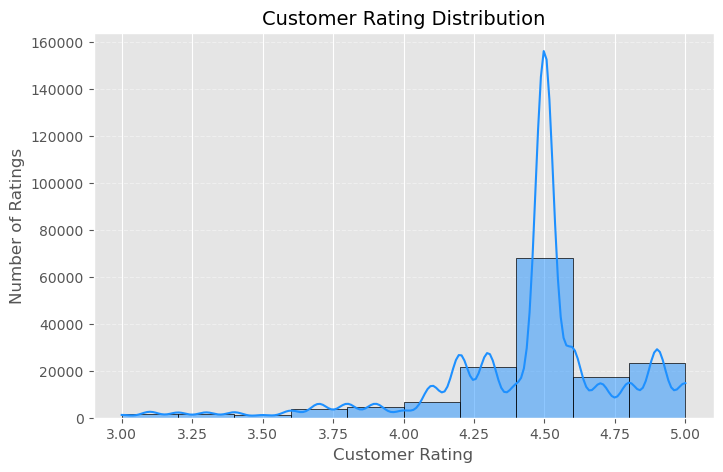

Customer Rating Statistics
count    150000.00
mean          4.44
std           0.35
min           3.00
25%           4.30
50%           4.50
75%           4.60
max           5.00
Name: Customer Rating, dtype: float64


In [168]:
# Customer Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Customer Rating',
    bins=10,
    kde=True,
    color='dodgerblue',
    edgecolor='black'
)

plt.title("Customer Rating Distribution", fontsize=14)
plt.xlabel("Customer Rating")
plt.ylabel("Number of Ratings")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Statistics
print("Customer Rating Statistics")
print(df['Customer Rating'].describe().round(2))

# 11. Driver Rating Analysis

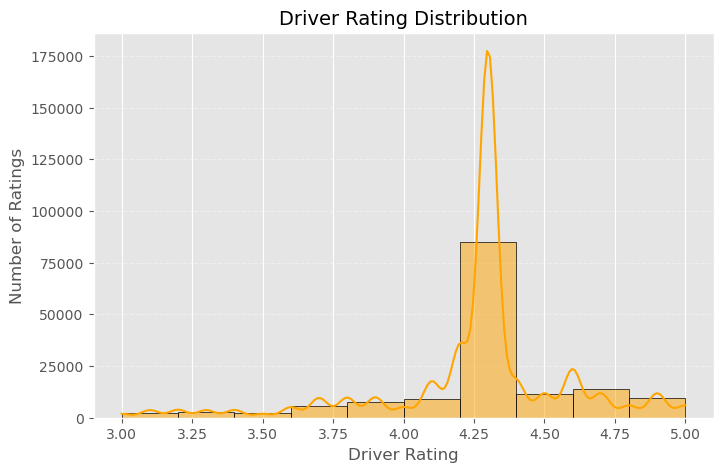

Driver Rating Statistics
count    150000.00
mean          4.26
std           0.35
min           3.00
25%           4.20
50%           4.30
75%           4.30
max           5.00
Name: Driver Ratings, dtype: float64


In [169]:
# Driver Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Driver Ratings',
    bins=10,
    kde=True,
    color='orange',
    edgecolor='black'
)

plt.title("Driver Rating Distribution", fontsize=14)
plt.xlabel("Driver Rating")
plt.ylabel("Number of Ratings")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Statistics
print("Driver Rating Statistics")
print(df['Driver Ratings'].describe().round(2))

# Comparison of Customer and Driver  Rating

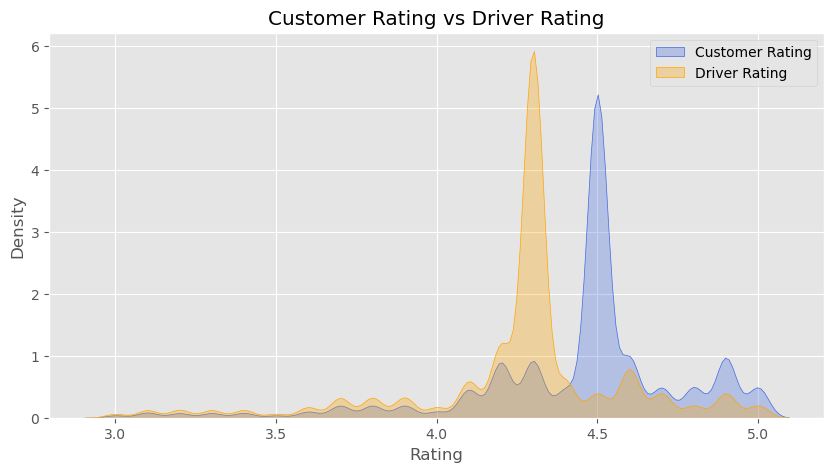

In [170]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='Customer Rating',
    label='Customer Rating',
    color='royalblue',
    fill=True,
    alpha=0.3
)

sns.kdeplot(
    data=df,
    x='Driver Ratings',
    label='Driver Rating',
    color='orange',
    fill=True,
    alpha=0.3
)

plt.title("Customer Rating vs Driver Rating")
plt.xlabel("Rating")
plt.ylabel("Density")
plt.legend()

plt.show()

# 12. Payment Method Analysis

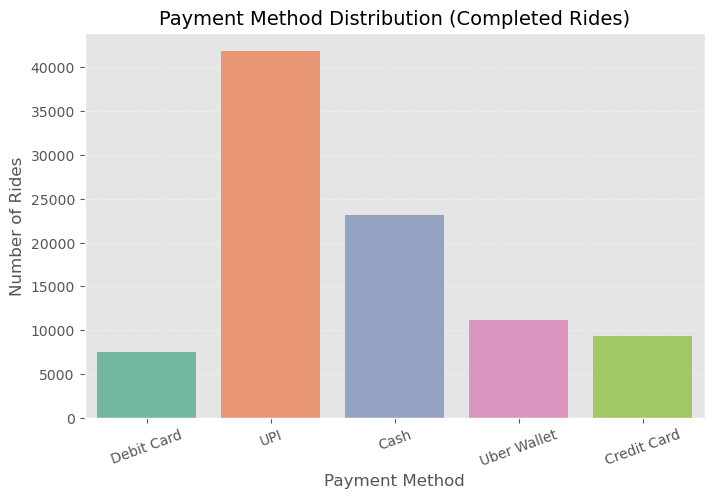

Payment Method Percentage (%)
Payment Method
UPI            44.98
Cash           24.85
Uber Wallet    12.05
Credit Card    10.02
Debit Card      8.09
Name: proportion, dtype: float64


In [171]:
# Payment Method Distribution (Completed Rides)

completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(8,5))

sns.countplot(
    data=completed,
    x='Payment Method',
    hue='Payment Method',
    palette='Set2',
    legend=False
)

plt.title("Payment Method Distribution (Completed Rides)", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Number of Rides")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Percentage
payment_percent = (
    completed['Payment Method']
    .value_counts(normalize=True) * 100
).round(2)

print("Payment Method Percentage (%)")
print(payment_percent)

# 13. Correlation HeatMap

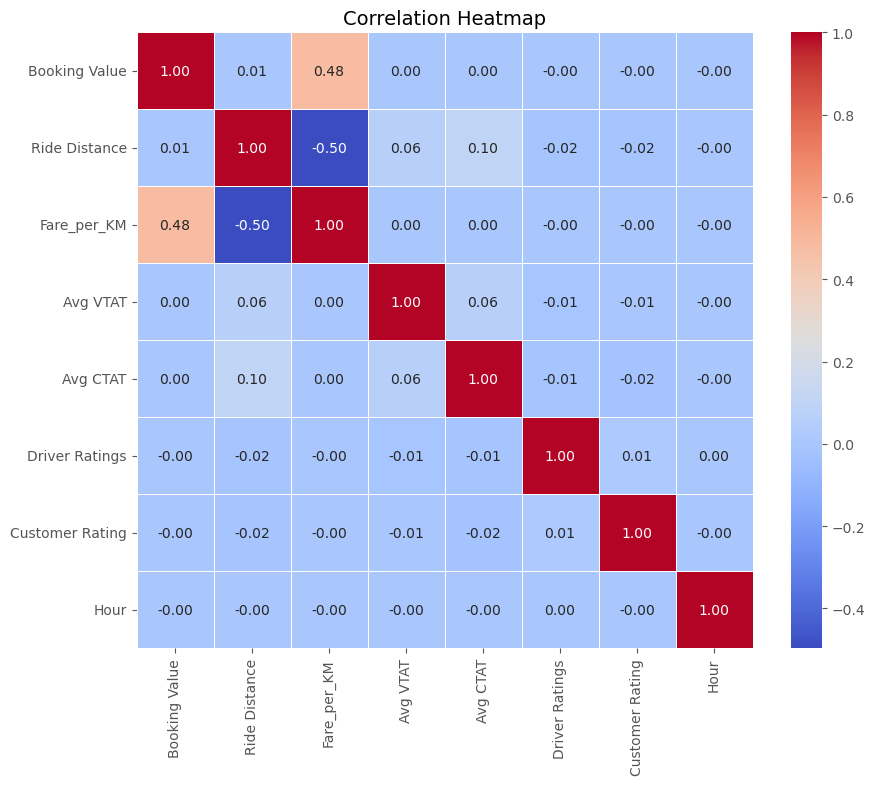

In [172]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

corr_columns = [
    'Booking Value',
    'Ride Distance',
    'Fare_per_KM',
    'Avg VTAT',
    'Avg CTAT',
    'Driver Ratings',
    'Customer Rating',
    'Hour'
]

correlation = df[corr_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap", fontsize=14)

plt.show()

# 14. Surge Detection

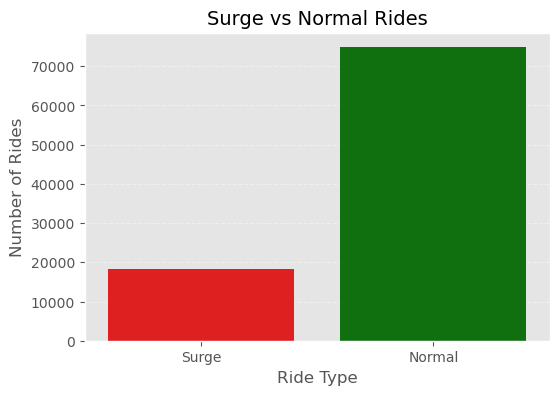

Surge Ride Percentage (%)
Surge
Normal    80.43
Surge     19.57
Name: proportion, dtype: float64

Average Fare per KM: ₹33.86


In [173]:
completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(6,4))

sns.countplot(
    data=completed,
    x='Surge',
    hue='Surge',
    palette={
        'Normal': 'green',
        'Surge': 'red'
    },
    legend=False
)

plt.title("Surge vs Normal Rides", fontsize=14)
plt.xlabel("Ride Type")
plt.ylabel("Number of Rides")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Percentage
surge_percent = (
    completed['Surge']
    .value_counts(normalize=True) * 100
).round(2)

print("Surge Ride Percentage (%)")
print(surge_percent)

# Average Fare per KM
average = completed['Fare_per_KM'].mean()

print(f"\nAverage Fare per KM: ₹{average:.2f}")

# 15. Revenue by Vehicle Type

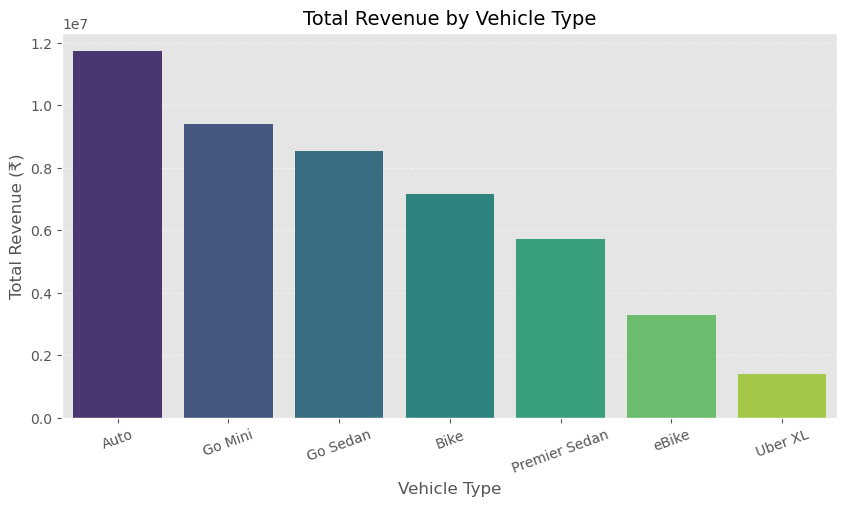

Revenue by Vehicle Type
Vehicle Type
Auto             11727615.0
Go Mini           9411418.0
Go Sedan          8538560.0
Bike              7144913.0
Premier Sedan     5733655.0
eBike             3298157.0
Uber XL           1406256.0
Name: Booking Value, dtype: float64


In [174]:
completed = df[df['Booking Status'] == 'Completed']

vehicle_revenue = (
    completed.groupby('Vehicle Type')['Booking Value']
             .sum()
             .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=vehicle_revenue.index,
    y=vehicle_revenue.values,
    hue=vehicle_revenue.index,
    palette='viridis',
    legend=False
)

plt.title("Total Revenue by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

print("Revenue by Vehicle Type")
print(vehicle_revenue.round(2))

# 16. Revenue by Hour

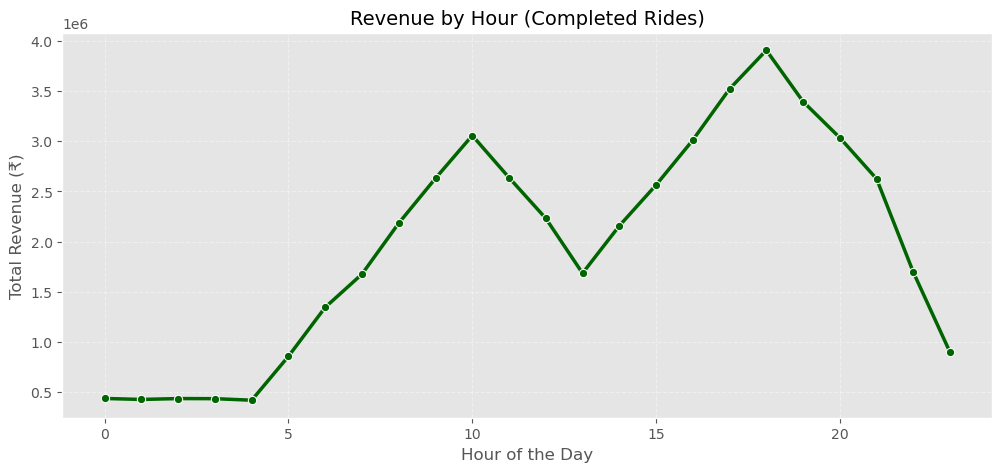

Revenue by Hour
    Hour  Booking Value
0      0       435728.0
1      1       425933.0
2      2       434751.0
3      3       433713.0
4      4       418249.0
5      5       856321.0
6      6      1344912.0
7      7      1675816.0
8      8      2183749.0
9      9      2631271.0
10    10      3057782.0
11    11      2637838.0
12    12      2231782.0
13    13      1684453.0
14    14      2156802.0
15    15      2564322.0
16    16      3012213.0
17    17      3522394.0
18    18      3908167.0
19    19      3395818.0
20    20      3035369.0
21    21      2625391.0
22    22      1693633.0
23    23       894167.0


In [175]:
completed = df[df['Booking Status'] == 'Completed']

hourly_revenue = (
    completed.groupby('Hour')['Booking Value']
             .sum()
             .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_revenue,
    x='Hour',
    y='Booking Value',
    marker='o',
    color='darkgreen',
    linewidth=2.5
)

plt.title("Revenue by Hour (Completed Rides)", fontsize=14)
plt.xlabel("Hour of the Day")
plt.ylabel("Total Revenue (₹)")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

print("Revenue by Hour")
print(hourly_revenue.round(2))

# 17. Top Pickup Location

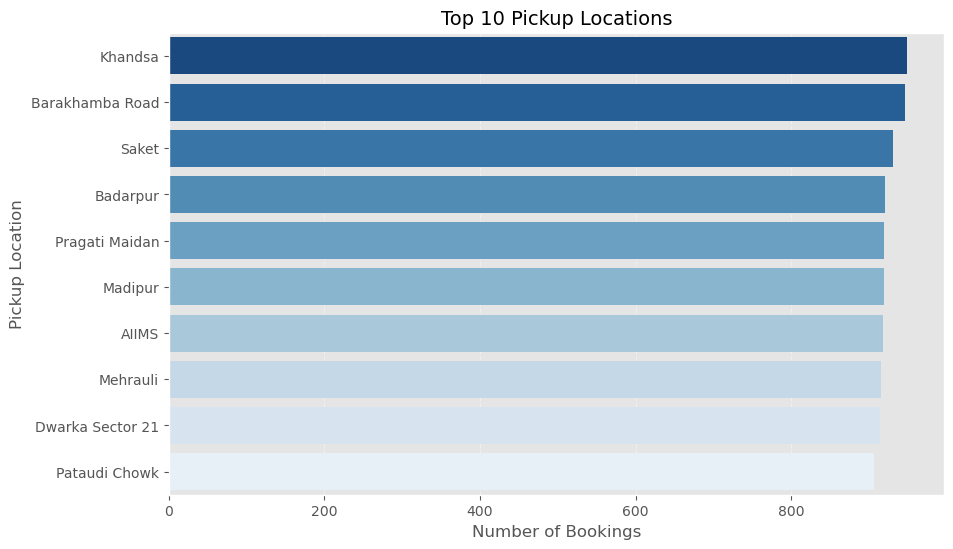

Top 10 Pickup Locations
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64


In [176]:
top_pickup = (
    df['Pickup Location']
      .value_counts()
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_pickup.values,
    y=top_pickup.index,
    hue=top_pickup.index,
    palette='Blues_r',
    legend=False
)

plt.title("Top 10 Pickup Locations", fontsize=14)
plt.xlabel("Number of Bookings")
plt.ylabel("Pickup Location")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

print("Top 10 Pickup Locations")
print(top_pickup)

# 18. Top Drop Location

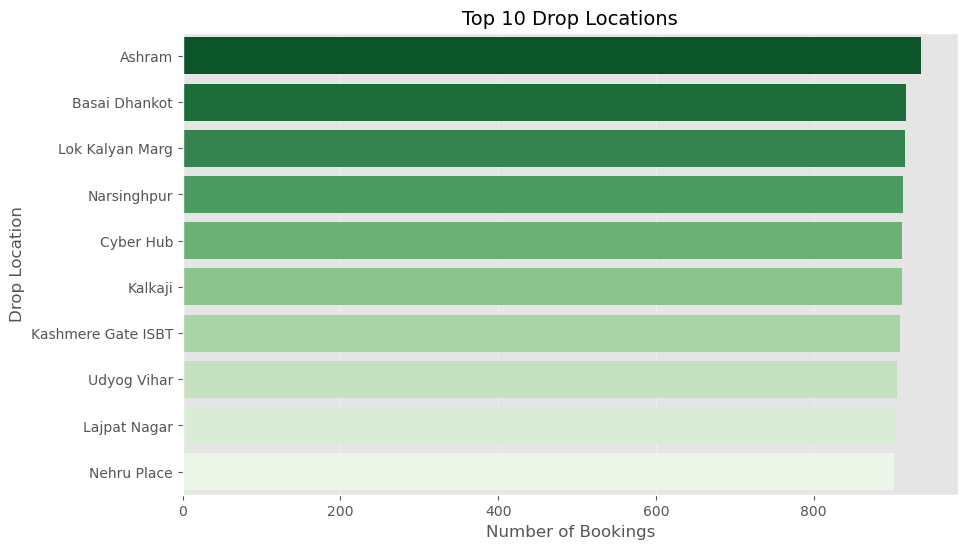

Top 10 Drop Locations
Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902
Name: count, dtype: int64


In [177]:
top_drop = (
    df['Drop Location']
      .value_counts()
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_drop.values,
    y=top_drop.index,
    hue=top_drop.index,
    palette='Greens_r',
    legend=False
)

plt.title("Top 10 Drop Locations", fontsize=14)
plt.xlabel("Number of Bookings")
plt.ylabel("Drop Location")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

print("Top 10 Drop Locations")
print(top_drop)

# 19. Customer Cancellation Reasons

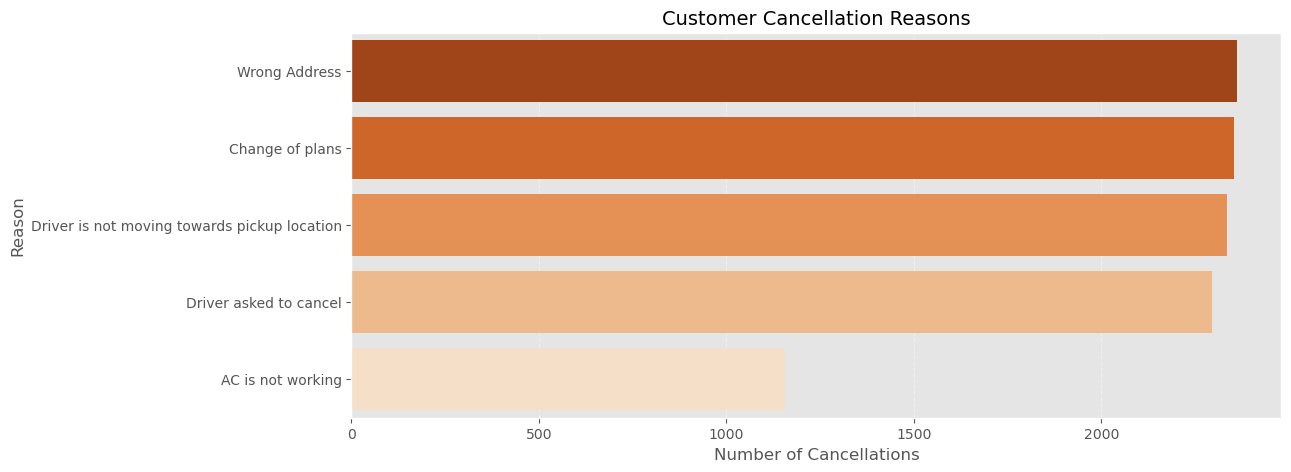

Customer Cancellation Reasons
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64


In [178]:
customer_cancel = (
    df.loc[
        df['Booking Status'] == 'Cancelled by Customer',
        'Reason for cancelling by Customer'
    ]
    .value_counts()
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=customer_cancel.values,
    y=customer_cancel.index,
    hue=customer_cancel.index,
    palette='Oranges_r',
    legend=False
)

plt.title("Customer Cancellation Reasons", fontsize=14)
plt.xlabel("Number of Cancellations")
plt.ylabel("Reason")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

print("Customer Cancellation Reasons")
print(customer_cancel)

# 20. Driver Cancellation Reasons

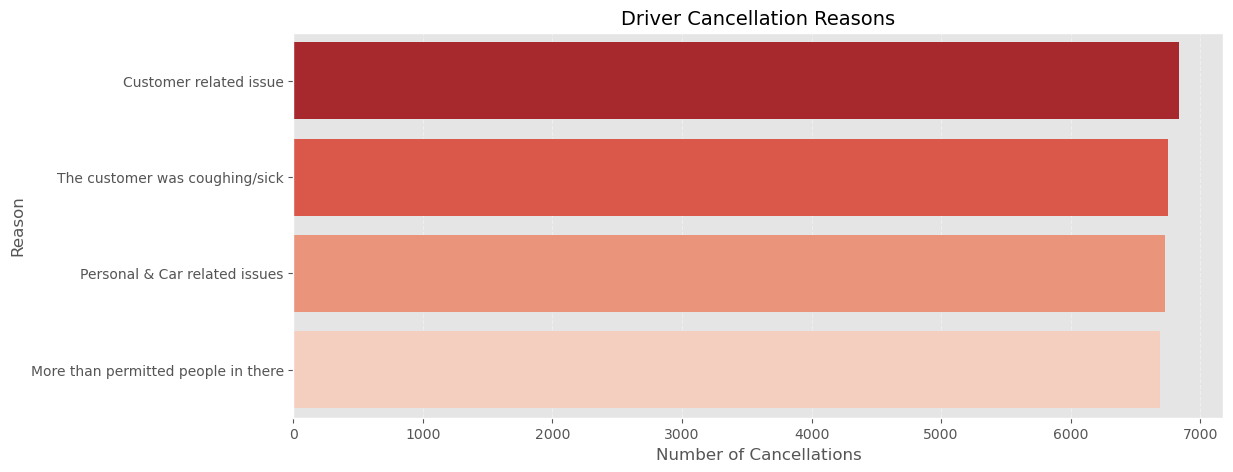

Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64


In [180]:
driver_cancel = (
    df.loc[
        df['Booking Status'] == 'Cancelled by Driver',
        'Driver Cancellation Reason'
    ]
    .value_counts()
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=driver_cancel.values,
    y=driver_cancel.index,
    hue=driver_cancel.index,
    palette='Reds_r',
    legend=False
)

plt.title("Driver Cancellation Reasons", fontsize=14)
plt.xlabel("Number of Cancellations")
plt.ylabel("Reason")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

print(driver_cancel)

# 21. Customer Rating by Vehicle Type

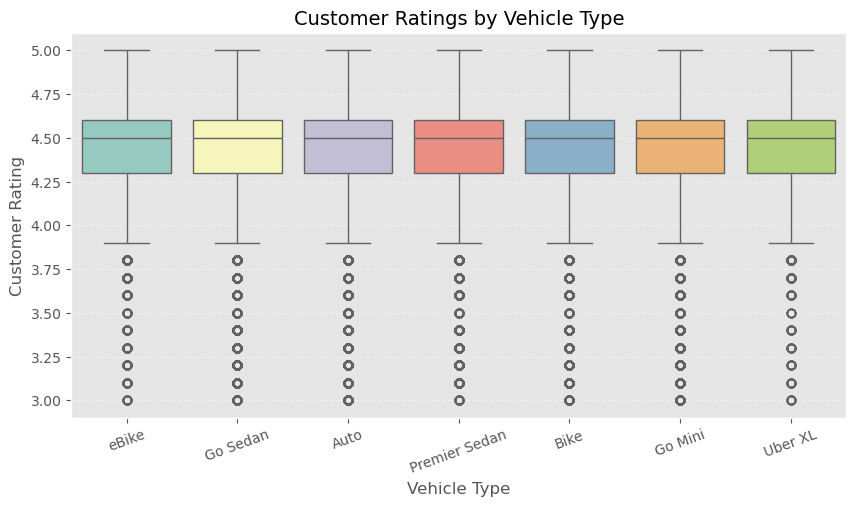

In [185]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='Vehicle Type',
    y='Customer Rating',
    hue='Vehicle Type',
    palette='Set3',
    legend=False
)

plt.title("Customer Ratings by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Customer Rating")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# 22. Fare per KM by Vehicle

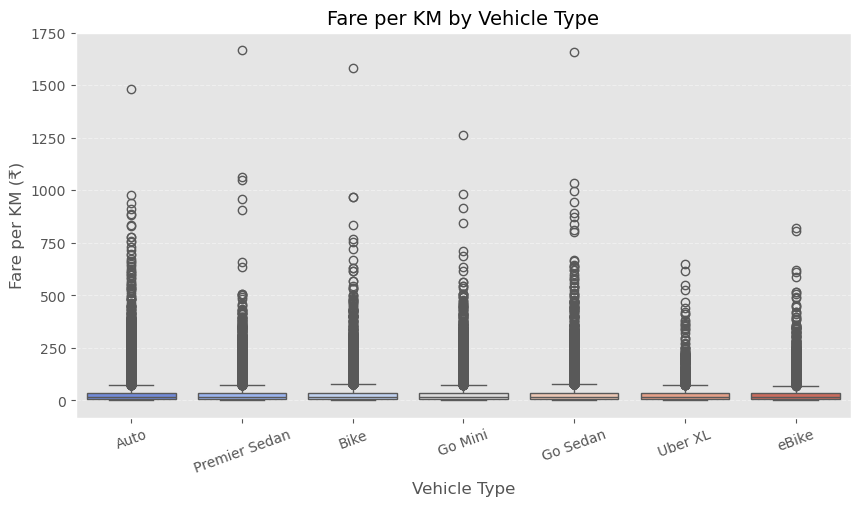

In [186]:
completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(10,5))

sns.boxplot(
    data=completed,
    x='Vehicle Type',
    y='Fare_per_KM',
    hue='Vehicle Type',
    palette='coolwarm',
    legend=False
)

plt.title("Fare per KM by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Fare per KM (₹)")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# 23. Weekday Revenue

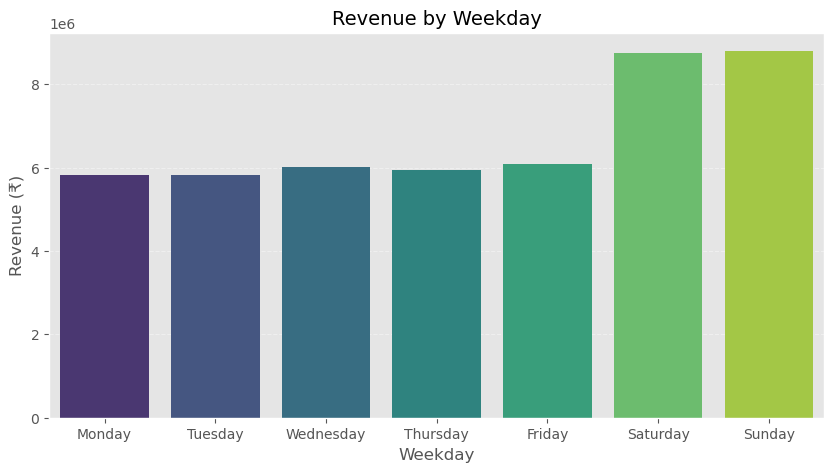

Weekday
Monday       5834906.0
Tuesday      5829233.0
Wednesday    6011228.0
Thursday     5956180.0
Friday       6090143.0
Saturday     8740187.0
Sunday       8798697.0
Name: Booking Value, dtype: float64


In [183]:
completed = df[df['Booking Status'] == 'Completed']

weekday_revenue = (
    completed.groupby('Weekday')['Booking Value']
             .sum()
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_revenue = weekday_revenue.reindex(weekday_order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_revenue.index,
    y=weekday_revenue.values,
    hue=weekday_revenue.index,
    palette='viridis',
    legend=False
)

plt.title("Revenue by Weekday", fontsize=14)
plt.xlabel("Weekday")
plt.ylabel("Revenue (₹)")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

print(weekday_revenue)

# 24. Surge Analysis By Hour

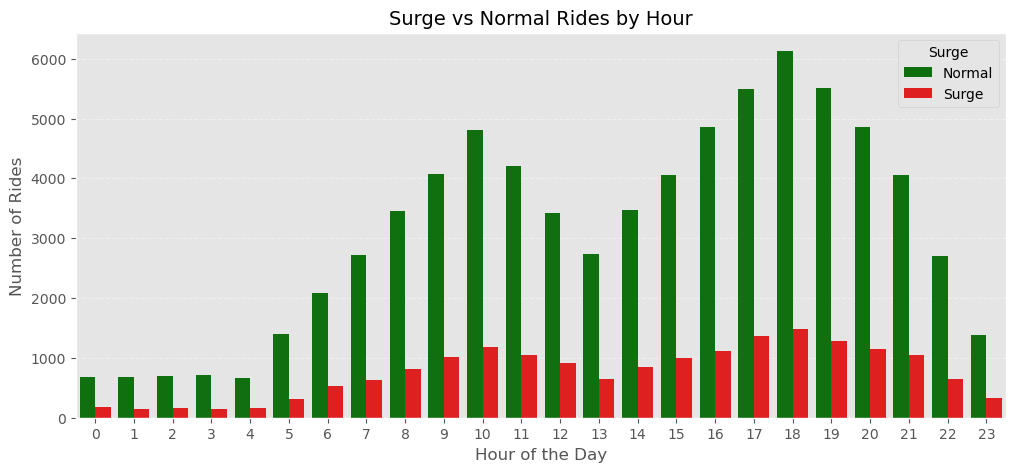

In [184]:
completed = df[df['Booking Status'] == 'Completed']

plt.figure(figsize=(12,5))

sns.countplot(
    data=completed,
    x='Hour',
    hue='Surge',
    palette={
        'Normal':'green',
        'Surge':'red'
    }
)

plt.title("Surge vs Normal Rides by Hour", fontsize=14)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Rides")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# OVERALL KPI'S

In [193]:
# ======================================================
#                    OVERALL KPIs
# ======================================================

completed = df[df['Booking Status'] == 'Completed']

total_bookings = len(df)
completed_rides = (df['Booking Status'] == 'Completed').sum()
completion_rate = (completed_rides / total_bookings) * 100

total_revenue = completed['Booking Value'].sum()

average_fare = completed['Booking Value'].mean()

average_distance = completed['Ride Distance'].mean()

average_customer_rating = df['Customer Rating'].mean()

average_driver_rating = df['Driver Ratings'].mean()

surge_percentage = (
    (completed['Surge'] == 'Surge').mean() * 100
)

print("=" * 50)
print("            OVERALL KPI'S")
print("=" * 50)

print(f"📌 Total Bookings           : {total_bookings:,}")
print(f"✅ Completed Rides          : {completed_rides:,}")
print(f"📈 Completion Rate          : {completion_rate:.2f}%")
print(f"💰 Total Revenue            : ₹{total_revenue:,.2f}")
print(f"💵 Average Fare             : ₹{average_fare:.2f}")
print(f"🛣️ Average Ride Distance    : {average_distance:.2f} KM")
print(f"⭐ Avg Customer Rating      : {average_customer_rating:.2f}")
print(f"🚖 Avg Driver Rating        : {average_driver_rating:.2f}")
print(f"⚡ Surge Ride Percentage    : {surge_percentage:.2f}%")

            OVERALL KPI'S
📌 Total Bookings           : 150,000
✅ Completed Rides          : 93,000
📈 Completion Rate          : 62.00%
💰 Total Revenue            : ₹47,260,574.00
💵 Average Fare             : ₹508.18
🛣️ Average Ride Distance    : 26.00 KM
⭐ Avg Customer Rating      : 4.44
🚖 Avg Driver Rating        : 4.26
⚡ Surge Ride Percentage    : 19.57%


In [188]:
#Export the cleaned dataset
output_path = r"C:\Users\kuzma\OneDrive\Desktop\DATA ANALYST\Ride_Fare_Surge_Analysis\data\ride_fare_surge_cleaned.csv"

df.to_csv(output_path, index=False)

print("Dataset exported successfully!")
print("Saved at:", output_path)

Dataset exported successfully!
Saved at: C:\Users\kuzma\OneDrive\Desktop\DATA ANALYST\Ride_Fare_Surge_Analysis\data\ride_fare_surge_cleaned.csv


In [194]:
distance_sort = {
    "0-5 KM": 1,
    "5-10 KM": 2,
    "10-15 KM": 3,
    "15-20 KM": 4,
    "20-25 KM": 5,
    "25-30 KM": 6,
    "30-40 KM": 7,
    "40-50 KM": 8
}

df["Distance Sort"] = df["Distance Category"].map(distance_sort)

In [195]:
df[["Distance Category", "Distance Sort"]].head(10)

,Distance Category,Distance Sort
0,NaN,NaN
1,NaN,NaN
2,10-15 KM,3
3,30-40 KM,7
4,40-50 KM,8
5,0-5 KM,1
6,40-50 KM,8
7,5-10 KM,2
8,NaN,NaN
9,NaN,NaN


In [196]:
df.to_csv("ride_fare_surge_cleaned.csv", index=False)